# FluxDisco example: Lotka-Volterra

To illustrate how FluxDisco may be used, we've provided an example using the Lotka-Volterra predator-prey model.

In [1]:
# %%capture
# # Install required packages
# ! pip install git+https://github.com/CassandraDurr/FluxDisco.git

In [2]:
import numpy as np
import pandas as pd
import sympy
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from fluxdisco import run_fluxdisco

We first need to simulate data for this system.

In [3]:
def lotka_volterra(
    par: list[float], time: np.ndarray, constants: tuple[float, float, float]
) -> list[float]:
    """Lotka-Volterra system of ODEs.

    Args:
        par (list[float]): Initial conditions for x and y (prey and predator populations).
        time (np.ndarray): Time points.
        constants (tuple[float, float, float]): Constants for the Lotka-Volterra system.

    Returns:
        list[float]: Derivatives of x and y.
    """
    a, b, c = constants
    x, y = par
    dxdt = a * x - b * x * y
    dydt = -c * y + b * x * y
    return [dxdt, dydt]

In [4]:
consts = (1.0, 0.1, 1.5)  # a, b, c
noise_level = 0.03
initial_conditions = [10.0, 5.0]
times = np.linspace(0, 30, 150)

In [5]:
# Simulate noiseless solution
clean_solution = odeint(lotka_volterra, initial_conditions, times, args=(consts,))

# Add noise
solution_range = np.ptp(clean_solution, axis=0)
noisy_solution = clean_solution + noise_level * solution_range * np.random.normal(
    size=clean_solution.shape
)

# Ensure positivity (all states >= 0.0)
noisy_solution = np.maximum(noisy_solution, 0.0)

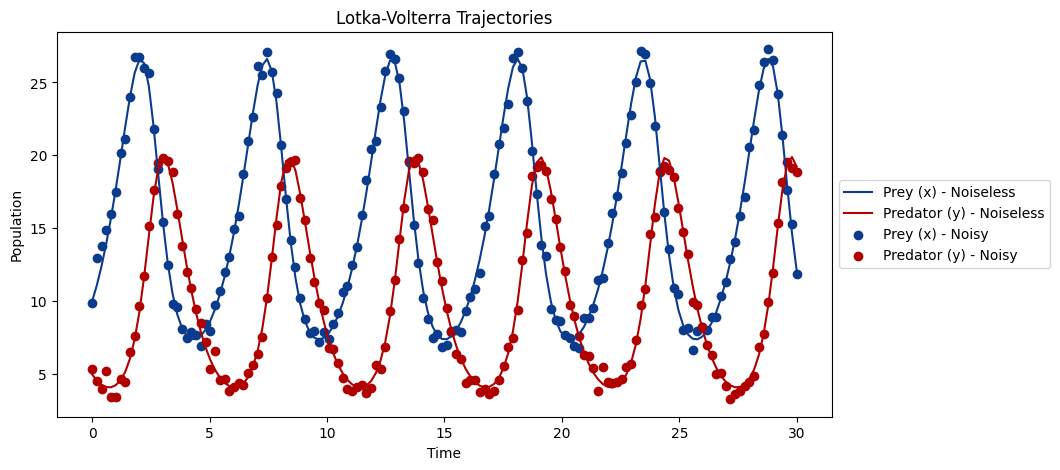

In [6]:
# Plot these trajectories
plt.figure(figsize=(10, 5))
plt.plot(times, clean_solution[:, 0], label="Prey (x) - Noiseless", color="#0B3B8D")
plt.plot(times, clean_solution[:, 1], label="Predator (y) - Noiseless", color="#B00000")
plt.scatter(times, noisy_solution[:, 0], label="Prey (x) - Noisy", color="#0B3B8D")
plt.scatter(times, noisy_solution[:, 1], label="Predator (y) - Noisy", color="#B00000")
plt.title("Lotka-Volterra Trajectories")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

Next, we need to define the data structure as expected by FluxDisco.

In [7]:
# Data for a single realisation (replication)
lv_data = [
    {
        "time": times,
        "initial_conditions": initial_conditions,
        "states": {  # Noisy trajectories for states x and y
            "x": noisy_solution[:, 0],
            "y": noisy_solution[:, 1],
        },
    }
]

Next, we define the system configuration parameters, including the system states, grammar rules and associated sampling probabilities, and the system stoichiometry.

In [8]:
# Define system configuration for FluxDisco
states = ["x", "y"]
x, y = sympy.symbols("x y")
grammar_rules = {
    "M": [f"M -> {state}" for state in states]
    + [
        "M -> C",
        "M -> M + M",  # Allow addition
        "M -> M - M",  # Allow subtraction
        "M -> M * M",  # Allow multiplication
    ],
}

# Grammar sampling probabilities for each flux
# (method normalises these to valid probabilities)
flux_priors = {
    0: {  # ax
        "M -> x": 1,
        "M -> y": 0,  # Exclude y from flux 0 (prior knowledge)
        "M -> C": 1,
        "M -> M + M": 1,
        "M -> M - M": 1,
        "M -> M * M": 1,
    },
    1: {  # bxy
        "M -> x": 1,
        "M -> y": 1,
        "M -> C": 1,
        "M -> M + M": 1,
        "M -> M - M": 1,
        "M -> M * M": 1,
    },
    2: {  # cy
        "M -> x": 0,  # Exclude x from flux 2 (prior knowledge)
        "M -> y": 1,
        "M -> C": 1,
        "M -> M + M": 1,
        "M -> M - M": 1,
        "M -> M * M": 1,
    },
}

system_config = {
    "states": states,
    "state_variables": [x, y],
    "state_to_variable": {"x": x, "y": y},
    "num_fluxes": 3,  # Number of fluxes in the system
    "system_structure": {"x": [1, -1, 0], "y": [0, 1, -1]},  # Stoichiometry
    "grammar": grammar_rules,
    "flux_priors": flux_priors,
}

The last thing we need to define is the search parameters. This step is optional as the method can use default parameters. Here, we limit the number of episodes for illustration purposes.

In [9]:
search_params = {"episodes": 5, "print_epi": 1}

Now we can run FluxDisco.

In [10]:
# Run experiment
top_equations, results_df = run_fluxdisco(
    data=lv_data,
    system_config=system_config,
    search_params=search_params,
    experiment_name="lotka_volterra_example",
    save_dir="example_results",
)

Starting FluxDisco search: lotka_volterra_example
Episode 0/5...
   Reached terminal node at step 24
Episode 1/5...
   Reached terminal node at step 10
Episode 2/5...
   Reached terminal node at step 15
Episode 3/5...
   Reached terminal node at step 2
Episode 4/5...
   Reached terminal node at step 3
Saved estimated data to example_results/lotka_volterra_example/estimated_data.csv
Time taken: 1176.17 seconds (19.60 min, 0.33 hr)

Finished lotka_volterra_example. Results saved to example_results/lotka_volterra_example


In [11]:
# Print the best equation found
top_system = top_equations[0][2]
true_expressions = [
    consts[0] * x,  # ax
    consts[1] * x * y,  # bxy
    consts[2] * y,  # cy
]
for flux_idx, flux_expr in enumerate(top_system):
    print(f"Flux {flux_idx}: {flux_expr}, Expected: {true_expressions[flux_idx]}")

Flux 0: 5.70899782270986e-5*x**2 + x - 0.0673598954532322, Expected: 1.0*x
Flux 1: 0.0991712866040208*x*y + 0.00138638123141824*y**2 - 0.0139759698063523*y, Expected: 0.1*x*y
Flux 2: 0.00217408469647341*y**2 + 1.46998128298519*y, Expected: 1.5*y


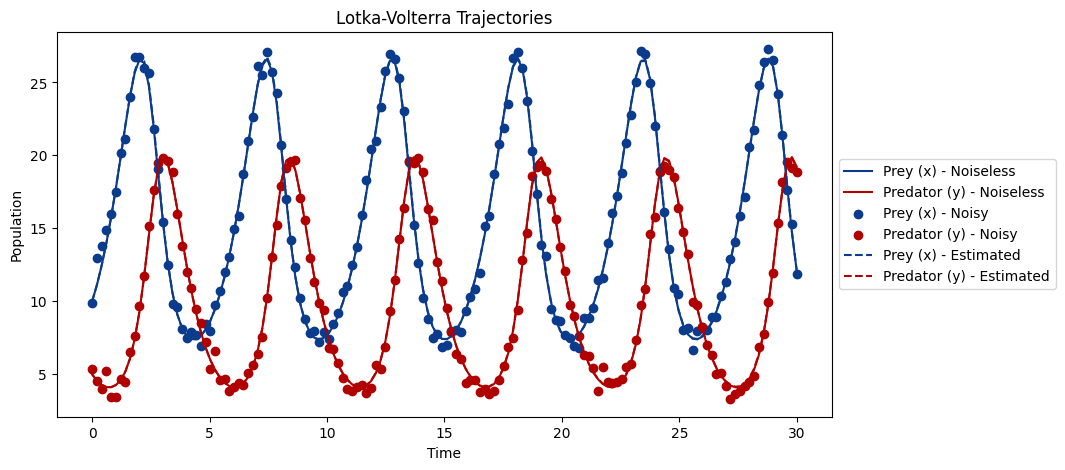

In [12]:
# Load the estimated data and plot alongside the original noisy data
estimated_data = pd.read_csv(
    "example_results/lotka_volterra_example/estimated_data.csv"
)

# Plot these trajectories
plt.figure(figsize=(10, 5))
# Noiseless solution
plt.plot(times, clean_solution[:, 0], label="Prey (x) - Noiseless", color="#0B3B8D")
plt.plot(times, clean_solution[:, 1], label="Predator (y) - Noiseless", color="#B00000")
# Noisy solution
plt.scatter(times, noisy_solution[:, 0], label="Prey (x) - Noisy", color="#0B3B8D")
plt.scatter(times, noisy_solution[:, 1], label="Predator (y) - Noisy", color="#B00000")
# Estimated solution
plt.plot(
    estimated_data["time"],
    estimated_data["estimated_X"],
    label="Prey (x) - Estimated",
    color="#0B3B8D",
    linestyle="--",
)
plt.plot(
    estimated_data["time"],
    estimated_data["estimated_Y"],
    label="Predator (y) - Estimated",
    color="#B00000",
    linestyle="--",
)
plt.title("Lotka-Volterra Trajectories")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()